<a href="https://colab.research.google.com/github/akinlayoadeniran/marketing-analytics-ml/blob/main/customer_segmentation_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using K-Means Clustering

**Project:** Data Science on Marketing ML  
**Author:** Adeniran Akinlayo Moses  
**School:** Facultet School  

## Objective
Group customers into meaningful segments based on their purchasing behaviour using the RFM framework:
- **R**ecency — how recently a customer made a purchase
- **F**requency — how often they purchase
- **M**onetary — how much they spend

## Dataset
We use the [Online Retail Dataset](https://www.kaggle.com/datasets/vijayuv/onlineretail) from Kaggle — a real transactional dataset from a UK-based online retailer.

## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Dataset

In [15]:
# Load dataset (download from Kaggle and place in the data/ folder)
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Exploratory Data Analysis (EDA)

In [16]:
# Basic info
print('Dataset Info:')
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [17]:
# Basic statistics
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 4. Data Cleaning

In [18]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'Cleaned dataset shape: {df.shape}')
df.head()

Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 5. RFM Analysis

In [19]:
# Reference date: one day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Compute RFM metrics per customer
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print('RFM Table:')
rfm.head(10)

RFM Table:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


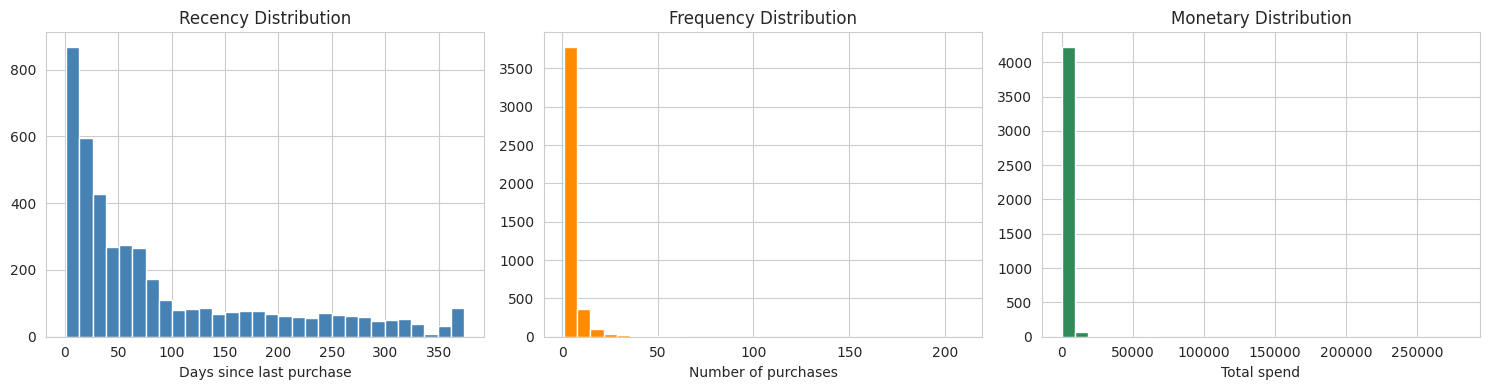

In [20]:
# Visualise RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['Frequency'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of purchases')

axes[2].hist(rfm['Monetary'], bins=30, color='seagreen', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend')

plt.tight_layout()
plt.show()

## 6. Feature Scaling

In [21]:
# Scale RFM features so K-Means isn't biased by large values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print('Scaled features (first 5 rows):')
print(rfm_scaled[:5])

Scaled features (first 5 rows):
[[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


## 7. Finding the Optimal Number of Clusters (Elbow Method)

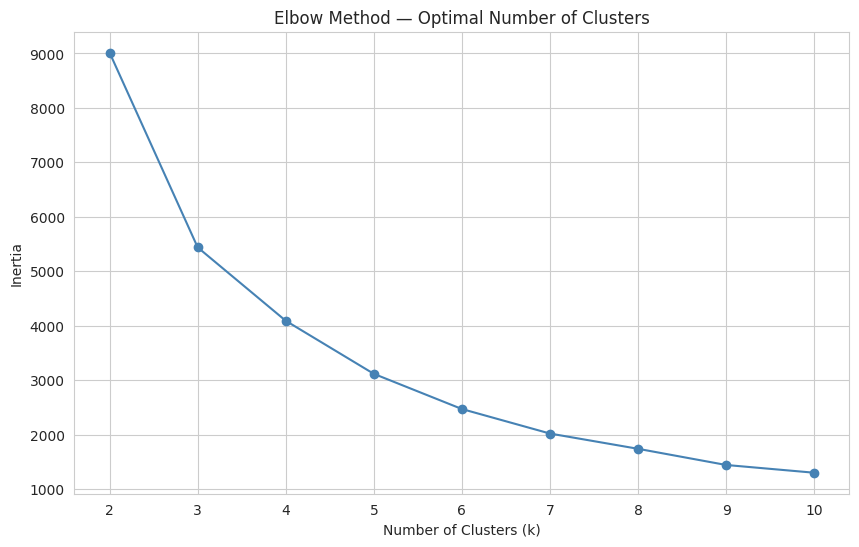

In [22]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

## 8. Train K-Means Model

In [23]:
# Train with k=4 (adjust based on elbow curve)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Silhouette score (closer to 1 = better)
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f'Silhouette Score: {score:.3f}')

rfm.head(10)

Silhouette Score: 0.616


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1
5,12352.0,36,8,2506.04,0
6,12353.0,204,1,89.00,1
7,12354.0,232,1,1079.40,1
8,12355.0,214,1,459.40,1
9,12356.0,23,3,2811.43,0


## 9. Analyse & Visualise Segments

In [24]:
# Segment summary
segment_summary = rfm.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(1)

print('Segment Summary:')
segment_summary

Segment Summary:


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.7,3.7,1359.0
1,1067,248.1,1.6,480.6
2,13,7.4,82.5,127338.3
3,204,15.5,22.3,12709.1


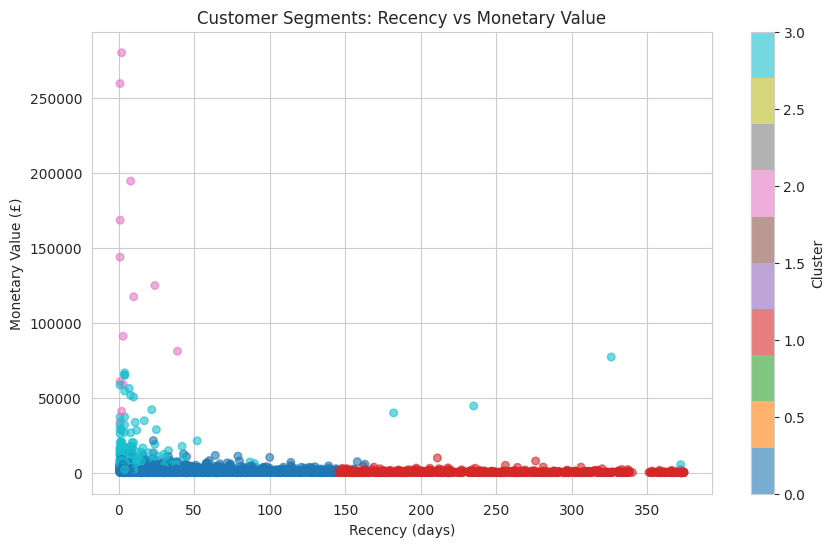

In [25]:
# Scatter plot: Recency vs Monetary, coloured by cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm['Recency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='tab10', alpha=0.6, s=30
)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments: Recency vs Monetary Value')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value (£)')
plt.show()

## 10. Conclusions

Based on the segmentation, we identified **4 customer groups**:

| Cluster | Description | Marketing Action |
|---|---|---|
| 0 | High value, frequent buyers | Loyalty rewards, VIP offers |
| 1 | Recent but low spend | Upsell campaigns |
| 2 | Churning customers | Re-engagement emails |
| 3 | Low engagement | Win-back discounts |

*(Update this table based on your actual cluster analysis results)*

## Next Steps
- Try different values of k and compare silhouette scores
- Add more features (product categories, location)
- Build a churn prediction model on top of these segments